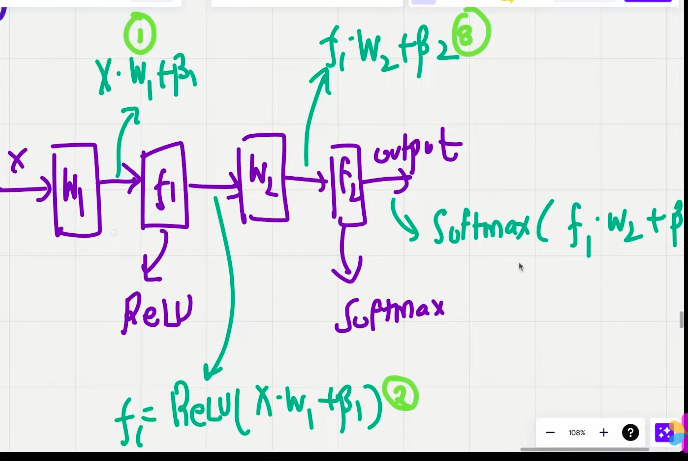

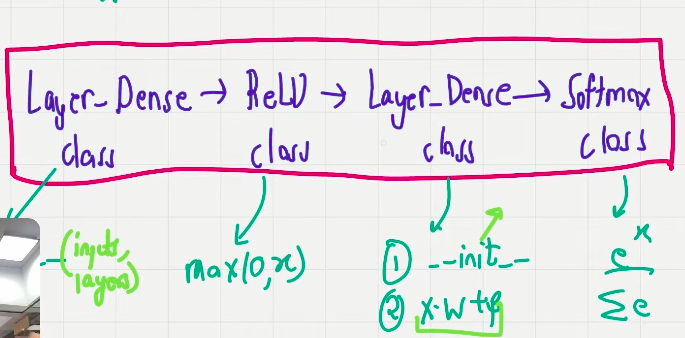

Input: You fed in $(x, y)$ coordinates.

Layer 1: It looked for simple patterns in those coordinates.

ReLU:  It decided which of those patterns were "interesting" enough to pass forward.Layer 2: It took those filtered patterns and tried to map them to our 3 spiral arms.

Softmax: It turned the final scores into a percentage (e.g., $0.33, 0.33, 0.34$).

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import nnfs
from nnfs.datasets import spiral_data
nnfs.init()

[[0.33333334 0.33333334 0.33333334]
 [0.33335656 0.33332282 0.33332065]
 [0.3333794  0.33331248 0.3333082 ]
 [0.33340728 0.3332996  0.3332931 ]
 [0.3334332  0.33328772 0.33327907]
 [0.3334524  0.33327925 0.33326837]
 [0.33347863 0.33326718 0.33325413]
 [0.33349758 0.33325735 0.33324507]
 [0.33353338 0.3332419  0.3332247 ]
 [0.33355746 0.33323097 0.33321154]]


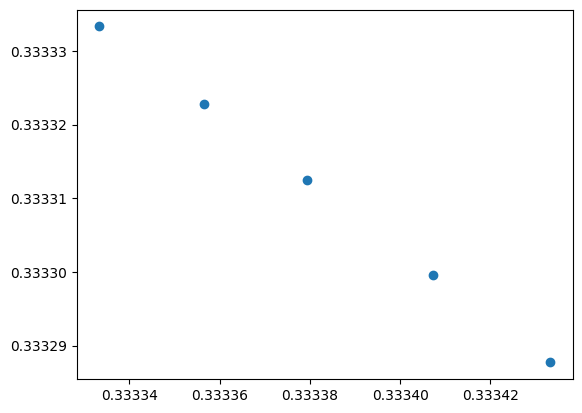

In [15]:
class layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
        #initializing weights and biases
    #Forward pass  #STEP 1
    def forward(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.biases
        #calculating output of the layer
    #STEP 2  ReLU ACTIVATION FUNCTION
    class activation_ReLU:
        def forward(self, inputs):
            self.output = np.maximum(0, inputs)
            #calculating output of the activation function
    class activation_Softmax:
        def forward(self, inputs):
            exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
            probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)
            self.output = probabilities

# Create dataset
x, y = spiral_data(samples=100, classes=3)
# Create Dense layer with 2 input features and 3 output values
dense1 = layer_Dense(2, 3)
# Create ReLU activation (to be used with Dense layer):
activation1 = layer_Dense.activation_ReLU()
# Make a forward pass of our training data through this layer
dense2 = layer_Dense(3, 3)

activation2 = layer_Dense.activation_Softmax()

#making forward pass through the first layer


dense1.forward(x)

activation1.forward(dense1.output)

dense2.forward(activation1.output)

activation2.forward(dense2.output)

print(activation2.output[:10])
#IN OUTPUT EACH ROW SUM WILL BE EQUAL TO 1 (SOFTMAX ACTIVATION FUNCTION)
plt.scatter(activation2.output[:5, 0], activation2.output[:5, 1])
plt.show()
